In [189]:
import pandas as pd
import numpy as np

# ========================= CONFIG =========================
DATA_PATH = "NN5_COMPLETE.xls"
SHEET_NAME = "NN3 COMPLETE Data"
SKIPROWS = 13
FORECAST_HORIZON = 56
# =======================================================

# Load dữ liệu
df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME, skiprows=SKIPROWS)

ts_data = df_raw.iloc[3:].copy()
ts_data.rename(columns={'Time Series #ID': 'Excel_Date'}, inplace=True)
ts_data['Date'] = pd.to_datetime(ts_data['Excel_Date'], errors='coerce')
ts_data.set_index('Date', inplace=True)
ts_data.drop(columns=['Excel_Date'], inplace=True)
ts_data = ts_data.astype(float)

print(f"✅ Loaded: {ts_data.shape[0]} days × {ts_data.shape[1]} ATMs")

# Long format
df_long = (ts_data.reset_index()
           .melt(id_vars='Date', 
                 var_name='ATM_ID', 
                 value_name='Withdrawal')
           .sort_values(['ATM_ID', 'Date'])
           .reset_index(drop=True))

# ====================== CHIA DỮ LIỆU ĐÚNG ======================
# 56 ngày cuối dành cho Submission (không có nhãn)
submission_df = df_long.groupby('ATM_ID').tail(FORECAST_HORIZON).copy()

# Phần dữ liệu có nhãn
data_with_gt = df_long.groupby('ATM_ID').head(-FORECAST_HORIZON).copy()

# Chia train / val / test internal theo thứ tự thời gian
test_df  = data_with_gt.groupby('ATM_ID').tail(FORECAST_HORIZON).copy()           # Test internal

# Lấy Val: 56 ngày ngay trước Test
val_df   = data_with_gt.groupby('ATM_ID').apply(
    lambda x: x.iloc[-FORECAST_HORIZON*2 : -FORECAST_HORIZON]
).reset_index(drop=True)

# Train: phần còn lại
train_df = data_with_gt.groupby('ATM_ID').apply(
    lambda x: x.iloc[:-FORECAST_HORIZON*2]
).reset_index(drop=True)

print(f"📊 Train shape       : {train_df.shape}")
print(f"📊 Val shape         : {val_df.shape}")
print(f"📊 Test (internal)   : {test_df.shape}")
print(f"📊 Submission shape  : {submission_df.shape}")

print(f"\nTrain date     : {train_df['Date'].min()} → {train_df['Date'].max()}")
print(f"Val date       : {val_df['Date'].min()} → {val_df['Date'].max()}")
print(f"Test date      : {test_df['Date'].min()} → {test_df['Date'].max()}")
print(f"Submission date: {submission_df['Date'].min()} → {submission_df['Date'].max()}")

✅ Loaded: 791 days × 111 ATMs
📊 Train shape       : (69153, 3)
📊 Val shape         : (6216, 3)
📊 Test (internal)   : (6216, 3)
📊 Submission shape  : (6216, 3)

Train date     : 1996-03-18 00:00:00 → 1997-11-30 00:00:00
Val date       : 1997-12-01 00:00:00 → 1998-01-25 00:00:00
Test date      : 1998-01-26 00:00:00 → 1998-03-22 00:00:00
Submission date: 1998-03-23 00:00:00 → 1998-05-17 00:00:00


In [230]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Đã bổ sung plot_pacf
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 0. DUMMY DATA GENERATION
# (Replace this with your actual dataframe: train_df)
# ==========================================
dates = pd.date_range(start='1996-03-01', end='1997-12-01', freq='D')
np.random.seed(42)
original_data = 18 + 5 * np.sin(np.arange(len(dates)) / 3.14) + np.random.normal(0, 3, len(dates))
shock_idx = (dates > '1996-12-15') & (dates < '1997-01-15')
original_data[shock_idx] -= 10 
train_df = pd.DataFrame({'Date': dates, 'Withdrawal': original_data, 'ATM_ID': 'ATM_001'})

# ==========================================
# 1. COLOR PALETTE & GLOBAL SETTINGS
# ==========================================
MAIN_BLUE = '#1f497d' 
LIGHT_GREY = '#d9d9d9'
TEXT_GREY = '#595959'  
AXIS_GREY = '#8c8c8c'  

sns.set_style("white") 
plt.rcParams['font.family'] = 'sans-serif' 
plt.rcParams['text.color'] = TEXT_GREY
plt.rcParams['axes.labelcolor'] = TEXT_GREY
plt.rcParams['xtick.color'] = TEXT_GREY
plt.rcParams['ytick.color'] = TEXT_GREY

def export_eda_plots_separated(train_df, atm_id=None):
    """
    Generate and export 6 separated EDA plots in English (including PACF), 
    following Storytelling with Data principles.
    """
    # Prepare Data
    df_plot = train_df.copy()
    if atm_id:
        series = df_plot[df_plot['ATM_ID'] == atm_id].set_index('Date')['Withdrawal'].dropna()
        context_str = f"(ATM: {atm_id})"
    else:
        series = df_plot.groupby('Date')['Withdrawal'].mean().dropna()
        context_str = "(Network Average)"

    last_date = series.index[-1]
    
    # ---------------------------------------------------------
    # PLOT 1: TREND & ORIGINAL DATA
    # ---------------------------------------------------------
    fig1, ax1 = plt.subplots(figsize=(12, 5))
    
    ax1.plot(series.index, series.values, color=LIGHT_GREY, linewidth=1)
    rolling_trend = series.rolling(window=28, center=True).mean()
    ax1.plot(rolling_trend.index, rolling_trend, color=MAIN_BLUE, linewidth=2.5)
    
    ax1.text(last_date + pd.Timedelta(days=5), series.values[-1], 'Original\nData', 
             color='#a6a6a6', fontsize=11, va='center')
    ax1.text(last_date + pd.Timedelta(days=5), rolling_trend.dropna().values[-1], 'Trend\n(28-day MA)', 
             color=MAIN_BLUE, fontsize=12, fontweight='bold', va='center')
    
    ax1.set_title(f"Despite stable weekly cycles, withdrawal demand plunges during the year-end holidays {context_str}", 
                  fontsize=14, fontweight='bold', color=MAIN_BLUE, loc='left', pad=15)
    ax1.set_ylabel('Withdrawal Volume', fontsize=11)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    sns.despine(ax=ax1)
    ax1.yaxis.grid(True, linestyle='-', color='#eeeeee')
    
    plt.tight_layout()
    plt.savefig('plot1_trend_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig1)

    # ---------------------------------------------------------
    # PLOT 2: AUTOCORRELATION (ACF)
    # ---------------------------------------------------------
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    
    plot_acf(series, lags=35, ax=ax2, color=MAIN_BLUE, vlines_kwargs={"colors": MAIN_BLUE}, alpha=0.05)
    
    ax2.set_title("Autocorrelation confirms a strict 7-day cyclical pattern in cash demand", 
                  fontsize=14, fontweight='bold', loc='left', pad=15)
    ax2.set_xlabel('Lag (Days)', fontsize=11)
    ax2.set_ylabel('ACF', fontsize=11)
    ax2.set_xticks(range(0, 36, 7))
    
    sns.despine(ax=ax2)
    ax2.grid(axis='y', linestyle='-', color='#eeeeee')
    for lag in range(7, 36, 7):
        ax2.axvline(lag, color=LIGHT_GREY, linestyle='--', linewidth=1, zorder=0)
        
    plt.tight_layout()
    plt.savefig('plot2_autocorrelation.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig2)

    # ---------------------------------------------------------
    # PLOT 3: PARTIAL AUTOCORRELATION (PACF)
    # ---------------------------------------------------------
    fig3, ax3 = plt.subplots(figsize=(10, 4))
    
    # Sử dụng method='ywm' để tính toán ổn định hơn, tránh warning
    plot_pacf(series, lags=35, ax=ax3, color=MAIN_BLUE, vlines_kwargs={"colors": MAIN_BLUE}, alpha=0.05, method='ywm')
    
    # Tiêu đề kể chuyện: PACF lọc bỏ nhiễu và chỉ ra chính xác lag 7 là quan trọng nhất
    ax3.set_title("", 
                  fontsize=14, fontweight='bold', loc='left', pad=15)
    ax3.set_xlabel('Lag (Days)', fontsize=11)
    ax3.set_ylabel('PACF', fontsize=11)
    ax3.set_xticks(range(0, 36, 7))
    
    sns.despine(ax=ax3)
    ax3.grid(axis='y', linestyle='-', color='#eeeeee')
    for lag in range(7, 36, 7):
        ax3.axvline(lag, color=LIGHT_GREY, linestyle='--', linewidth=1, zorder=0)
        
    plt.tight_layout()
    plt.savefig('plot3_partial_autocorrelation.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig3)

    # ---------------------------------------------------------
    # PLOT 4: VOLATILITY
    # ---------------------------------------------------------
    fig4, ax4 = plt.subplots(figsize=(12, 4))
    
    vol_short = series.rolling(window=7).std()
    vol_long = series.rolling(window=28).std()
    
    ax4.plot(vol_short.index, vol_short, color=LIGHT_GREY, linewidth=1)
    ax4.plot(vol_long.index, vol_long, color='#e74c3c', linewidth=2)
    
    ax4.text(last_date + pd.Timedelta(days=5), vol_long.dropna().values[-1], 'Long-term Volatility\n(Risk Indicator)', 
             color='#e74c3c', fontsize=11, fontweight='bold', va='center')
    
    ax4.set_title(f"Network volatility (cash-out risk) explodes during the transition into the New Year {context_str}", 
                  fontsize=14, fontweight='bold', loc='left', pad=15)
    ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    sns.despine(ax=ax4)
    ax4.yaxis.grid(True, linestyle='-', color='#eeeeee')
    
    plt.tight_layout()
    plt.savefig('plot4_volatility.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig4)

    # ---------------------------------------------------------
    # DATA PREP FOR BOXPLOTS
    # ---------------------------------------------------------
    df_box = series.reset_index()
    df_box['DayOfWeek'] = df_box['Date'].dt.day_name()
    df_box['Month'] = df_box['Date'].dt.month_name()
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                    'July', 'August', 'September', 'October', 'November', 'December']

    # ---------------------------------------------------------
    # PLOT 5: WEEKLY SEASONALITY
    # ---------------------------------------------------------
    fig5, ax5 = plt.subplots(figsize=(10, 5))
    
    sns.boxplot(data=df_box, y='DayOfWeek', x='Withdrawal', order=days_order, ax=ax5, 
                color='#e6ecf3', orient='h', 
                medianprops={'color': MAIN_BLUE, 'linewidth': 2},
                flierprops={'markerfacecolor': AXIS_GREY, 'markeredgecolor': 'none', 'markersize': 3})
    
    ax5.set_title("Intra-week demand steadily accumulates, peaking on Fridays", 
                  fontsize=14, fontweight='bold', loc='left', pad=15)
    ax5.set_ylabel('')
    ax5.set_xlabel('Withdrawal Volume', fontsize=11)
    
    sns.despine(ax=ax5, left=True)
    ax5.xaxis.grid(True, linestyle='-', color='#eeeeee')
    
    plt.tight_layout()
    plt.savefig('plot5_weekly_seasonality.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig5)

    # ---------------------------------------------------------
    # PLOT 6: MONTHLY SEASONALITY
    # ---------------------------------------------------------
    fig6, ax6 = plt.subplots(figsize=(10, 6))
    
    sns.boxplot(data=df_box, y='Month', x='Withdrawal', order=months_order, ax=ax6, 
                color='#e6ecf3', orient='h', 
                medianprops={'color': MAIN_BLUE, 'linewidth': 2},
                flierprops={'markerfacecolor': AXIS_GREY, 'markeredgecolor': 'none', 'markersize': 3})
    
    ax6.set_title("December exhibits extreme variance, followed by a sharp drop in January", 
                  fontsize=14, fontweight='bold', loc='left', pad=15)
    ax6.set_ylabel('')
    ax6.set_xlabel('Withdrawal Volume', fontsize=11)
    
    sns.despine(ax=ax6, left=True)
    ax6.xaxis.grid(True, linestyle='-', color='#eeeeee')
    
    plt.tight_layout()
    plt.savefig('plot6_monthly_seasonality.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig6)

    print("✅ Successfully exported 6 separate plots:")
    print("  1. plot1_trend_analysis.png")
    print("  2. plot2_autocorrelation.png")
    print("  3. plot3_partial_autocorrelation.png")
    print("  4. plot4_volatility.png")
    print("  5. plot5_weekly_seasonality.png")
    print("  6. plot6_monthly_seasonality.png")

# ==========================================
# EXECUTION
# ==========================================
export_eda_plots_separated(train_df, atm_id=None)

✅ Successfully exported 6 separate plots:
  1. plot1_trend_analysis.png
  2. plot2_autocorrelation.png
  3. plot3_partial_autocorrelation.png
  4. plot4_volatility.png
  5. plot5_weekly_seasonality.png
  6. plot6_monthly_seasonality.png


In [190]:
# # Kiểm tra missing values trong từng tập và suy ra % missing
# for name, df in zip(['Train', 'Val', 'Test (internal)'], [train_df, val_df, test_df]):
#     total = df.shape[0]
#     missing = df['Withdrawal'].isna().sum()
#     print(f"{name}: {missing} missing values ({missing/total:.2%})")

In [191]:
# # Kiểm tra duplicate trong từng tập
# for name, df in zip(['Train', 'Val', 'Test (internal)'], [train_df, val_df, test_df]):
#     duplicates = df.duplicated(subset=['ATM_ID', 'Date']).sum()
#     print(f"{name}: {duplicates} duplicate rows")

In [192]:
# # In ra .info() và .describe() cho từng tập
# for name, df in zip(['Train', 'Val', 'Test (internal)'], [train_df, val_df, test_df]):
#     print(f"\n{name} info:")
#     print(df.info())
#     print(f"\n{name} describe:")
#     print(df['Withdrawal'].describe())

In [193]:
import pandas as pd
import numpy as np

def create_features(df: pd.DataFrame, is_train=False):
    """
    Tạo features toàn diện: Time, UK Holidays, Lags, Rolling.
    An toàn 100% chống rò rỉ dữ liệu (No Data Leakage).
    """
    df = df.copy()
    df = df.sort_values(['ATM_ID', 'Date'])
    
    # =======================================================
    # 1. TIME & UK HOLIDAY FEATURES (Không bao giờ bị Leak)
    # =======================================================
    # Các biến thời gian cơ bản
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['day_of_month'] = df['Date'].dt.day
    df['month'] = df['Date'].dt.month
    df['is_payday'] = df['day_of_month'].isin([1, 15, 25, 28, 30, 31]).astype(int)
    
    # Danh sách Bank Holidays UK (1996 - 1998)
    uk_holidays = pd.to_datetime([
        '1996-01-01', '1996-04-05', '1996-04-08', '1996-05-06', '1996-05-27', '1996-08-26', '1996-12-25', '1996-12-26',
        '1997-01-01', '1997-03-28', '1997-03-31', '1997-05-05', '1997-05-26', '1997-08-25', '1997-12-25', '1997-12-26',
        '1998-01-01', '1998-04-10', '1998-04-13', '1998-05-04', '1998-05-25', '1998-08-31', '1998-12-25', '1998-12-26'
    ])
    df['is_uk_holiday'] = df['Date'].isin(uk_holidays).astype(int)
    
    # Đếm ngược đến Giáng Sinh (Chỉ kích hoạt trong tháng 12)
    df['days_until_xmas'] = df['Date'].apply(
        lambda x: (pd.to_datetime(f"{x.year}-12-25") - x).days if x.month == 12 and x.day <= 25 else 0
    )
    
    # Đánh dấu mùa Lễ hội (Festive Season) - Bẻ gãy chu kỳ thường
    df['is_festive_season'] = (
        ((df['Date'].dt.month == 12) & (df['Date'].dt.day >= 20)) | 
        ((df['Date'].dt.month == 1) & (df['Date'].dt.day <= 2))
    ).astype(int)
    
    # Ngày vàng mua sắm Boxing Day
    df['is_boxing_day'] = ((df['Date'].dt.month == 12) & (df['Date'].dt.day == 26)).astype(int)

    # =======================================================
    # 2. XỬ LÝ TARGET GỌN GÀNG (Chuẩn bị nguyên liệu cho Lag/Rolling)
    # =======================================================
    df['Withdrawal_clean'] = df.groupby('ATM_ID')['Withdrawal'].ffill()
    if is_train:
        df['Withdrawal_clean'] = df.groupby('ATM_ID')['Withdrawal_clean'].bfill()
        
    # =======================================================
    # 3. LAG FEATURES
    # =======================================================
    lags = [1, 7, 14, 28, 56]
    for lag in lags:
        df[f'lag_{lag}'] = df.groupby('ATM_ID')['Withdrawal_clean'].shift(lag)
    
    # =======================================================
    # 4. ROLLING FEATURES (Bắt buộc phải SHIFT 1 ngày)
    # =======================================================
    windows = [7, 14, 28]
    for window in windows:
        shifted_series = df.groupby('ATM_ID')['Withdrawal_clean'].shift(1)
        
        df[f'rolling_mean_{window}'] = shifted_series.groupby(df['ATM_ID']).transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        df[f'rolling_std_{window}'] = shifted_series.groupby(df['ATM_ID']).transform(
            lambda x: x.rolling(window, min_periods=1).std()
        )
    
    # =======================================================
    # 5. XỬ LÝ NaN VÀ DỌN DẸP
    # =======================================================
    feature_cols = [col for col in df.columns if col not in ['Date', 'ATM_ID', 'Withdrawal', 'Withdrawal_clean']]
    
    # Ffill cho các giá trị rolling/lag
    df[feature_cols] = df.groupby('ATM_ID')[feature_cols].ffill()
    
    # Lấp toàn bộ NaN còn sót lại bằng 0
    df[feature_cols] = df[feature_cols].fillna(0) 
    
    # Xóa cột nháp
    df.drop(columns=['Withdrawal_clean'], inplace=True)
    
    return df

In [194]:
# 1. Gọi hàm tạo feature TRÊN TOÀN BỘ DỮ LIỆU LIỀN MẠCH
print("🔄 Đang tạo features trên toàn bộ trục thời gian liền mạch...")
full_feat_df = create_features(data_with_gt)

# 2. CẮT DỮ LIỆU CƠ BẢN
FORECAST_HORIZON = 56
print("✂️ Đang cắt dữ liệu thành Train/Val/Test...")

test_feat = full_feat_df.groupby('ATM_ID').tail(FORECAST_HORIZON).copy()

val_feat = full_feat_df.groupby('ATM_ID').apply(
    lambda x: x.iloc[-FORECAST_HORIZON*2 : -FORECAST_HORIZON]
).reset_index(drop=True)

# Đây là tập Train gốc (vẫn chứa NaN, giữ nguyên cấu trúc thời gian)
train_raw = full_feat_df.groupby('ATM_ID').apply(
    lambda x: x.iloc[:-FORECAST_HORIZON*2]
).reset_index(drop=True)


# ====================================================================
# 3. TÁCH LUỒNG 1: DÀNH CHO MÔ HÌNH THỐNG KÊ (ARIMA / SARIMAX)
# ====================================================================
print("📈 Chuẩn bị dữ liệu cho Statistical Models (ARIMA/SARIMAX)...")
train_ts = train_raw.copy()

# Sử dụng Interpolation (Nội suy tuyến tính) để lấp NaN thay vì xóa
# Điều này giúp nối một đường thẳng giữa ngày t-1 và ngày t+1 nếu ngày t bị thiếu
train_ts['Withdrawal'] = train_ts.groupby('ATM_ID')['Withdrawal'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

# ====================================================================
# 4. TÁCH LUỒNG 2: DÀNH CHO MACHINE LEARNING (LIGHTGBM / XGBOOST)
# ====================================================================
print("🤖 Chuẩn bị dữ liệu cho Machine Learning (LightGBM)...")
train_ml = train_raw.copy()

# Xóa bỏ hoàn toàn các dòng NaN để mô hình không học nhầm dữ liệu nội suy giả
train_ml = train_ml.dropna(subset=['Withdrawal'])

# ====================================================================

print(f"\n✅ Hoàn tất! Số lượng NaN ở cột Withdrawal:")
print(f"  - Tập Train (Time Series) : {train_ts['Withdrawal'].isna().sum()} (Đã nội suy)")
print(f"  - Tập Train (Machine Learn): {train_ml['Withdrawal'].isna().sum()} (Đã xóa dòng)")
print(f"  - Tập Val (Chấm điểm)     : {val_feat['Withdrawal'].isna().sum()} (Giữ nguyên)")
print(f"  - Tập Test (Chấm điểm)    : {test_feat['Withdrawal'].isna().sum()} (Giữ nguyên)")

🔄 Đang tạo features trên toàn bộ trục thời gian liền mạch...
✂️ Đang cắt dữ liệu thành Train/Val/Test...
📈 Chuẩn bị dữ liệu cho Statistical Models (ARIMA/SARIMAX)...
🤖 Chuẩn bị dữ liệu cho Machine Learning (LightGBM)...

✅ Hoàn tất! Số lượng NaN ở cột Withdrawal:
  - Tập Train (Time Series) : 0 (Đã nội suy)
  - Tập Train (Machine Learn): 0 (Đã xóa dòng)
  - Tập Val (Chấm điểm)     : 75 (Giữ nguyên)
  - Tập Test (Chấm điểm)    : 81 (Giữ nguyên)


In [195]:
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

def check_stationarity_train_only(train_wide, significance=0.05):
    """
    Kiểm tra tính dừng CHỈ trên tập Train để tránh Data Leakage.
    """
    stationary_info = {}
    
    print("🔍 Đang kiểm tra tính dừng cho 111 ATM (Chỉ trên TRAIN)...\n")
    
    for atm in train_wide.columns:
        train_series = train_wide[atm].dropna()
        
        results = {'atm': atm}
        
        if len(train_series) < 20:
            results['train'] = False
            results['d'] = 1
        else:
            # Chỉ kiểm tra trên tập Train
            stat, pvalue, _, _, _, _ = adfuller(train_series, autolag='AIC')
            is_stationary = pvalue < significance
            
            results['train'] = is_stationary
            results['d'] = 0 if is_stationary else 1
            
        stationary_info[atm] = results
    
    # Thống kê
    stationary_count = sum(1 for v in stationary_info.values() if v['train'])
    needs_diff_count = sum(1 for v in stationary_info.values() if v['d'] == 1)
    
    print(f"📊 Kết quả kiểm tra Stationarity (Train-only):")
    print(f"   ✅ Train Stationary : {stationary_count} ATM (d=0)")
    print(f"   🔄 Cần differencing : {needs_diff_count} ATM (d=1)")
    
    return stationary_info

# Thực thi an toàn
train_wide = train_df.pivot(index='Date', columns='ATM_ID', values='Withdrawal')
stationarity_info_safe = check_stationarity_train_only(train_wide)

🔍 Đang kiểm tra tính dừng cho 111 ATM (Chỉ trên TRAIN)...

📊 Kết quả kiểm tra Stationarity (Train-only):
   ✅ Train Stationary : 104 ATM (d=0)
   🔄 Cần differencing : 7 ATM (d=1)


In [196]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model_comprehensive(model_name, train_df, val_df, test_df, predictions_dict=None):
    # 1. LẤY TRƯỚC NAIVE BASELINE (Truy xuất O(1) thay vì quét O(N))
    last_train_vals = train_df.dropna(subset=['Withdrawal']).groupby('ATM_ID')['Withdrawal'].last()
    
    val_wide = val_df.pivot(index='Date', columns='ATM_ID', values='Withdrawal')
    test_wide = test_df.pivot(index='Date', columns='ATM_ID', values='Withdrawal')
    
    print(f"\n=== {model_name} EVALUATION ===")
    print(f"{'Tập':<12} {'SMAPE':<8} {'MAE':<8} {'RMSE':<8} {'Bias':<8}")
    print("-" * 55)
    
    for name, df_wide in [('Val', val_wide), ('Test', test_wide)]:
        smape_list, mae_list, rmse_list, bias_list = [], [], [], []
        
        # 2. LINH HOẠT CHÂN TRỜI DỰ BÁO (Không hardcode 56)
        horizon = len(df_wide) 
        
        for atm in df_wide.columns:
            actual = df_wide[atm].values
            
            # Xử lý lấy giá trị dự báo
            if predictions_dict is not None and atm in predictions_dict:
                pred = np.array(predictions_dict[atm])
                pred = pred[-horizon:] if len(pred) >= horizon else np.full(horizon, np.nan)
            else:
                last_val = last_train_vals.get(atm, 0) # Tra cứu siêu tốc
                pred = np.full(horizon, last_val)
            
            # 3. GỘP LOGIC LỌC NaN CHUNG
            mask = ~np.isnan(actual) & ~np.isnan(pred)
            
            if np.sum(mask) > 5: # Chỉ tính nếu có đủ dữ liệu hợp lệ
                a_clean = actual[mask]
                p_clean = pred[mask]
                
                # Tính SMAPE trực tiếp
                denom = np.abs(a_clean) + np.abs(p_clean)
                smape_arr = np.where(denom == 0, 0, np.abs(a_clean - p_clean) / denom)
                
                smape_list.append(np.mean(smape_arr) * 200)
                mae_list.append(mean_absolute_error(a_clean, p_clean))
                rmse_list.append(np.sqrt(mean_squared_error(a_clean, p_clean)))
                bias_list.append(np.mean(p_clean - a_clean)) 
            else:
                smape_list.append(np.nan)
                mae_list.append(np.nan)
                rmse_list.append(np.nan)
                bias_list.append(np.nan)
        
        # In tổng kết
        print(f"{name:<12} "
              f"{np.nanmean(smape_list):<8.2f} "
              f"{np.nanmean(mae_list):<8.2f} "
              f"{np.nanmean(rmse_list):<8.2f} "
              f"{np.nanmean(bias_list):<8.2f}")
    
    print("-" * 55)

In [197]:
from tqdm import tqdm

def evaluate_arima_baseline_fixed(train_df, test_df, stationarity_info):
    predictions = {}
    smape_scores = []
    diff_applied = {} 
    
    print("🚀 Đang chạy ARIMA Baseline (Đã fix lỗi logic)...\n")
    
    train_wide = train_df.pivot(index='Date', columns='ATM_ID', values='Withdrawal')
    test_wide = test_df.pivot(index='Date', columns='ATM_ID', values='Withdrawal')
    
    failed_count = 0
    
    for atm in tqdm(train_wide.columns, desc="ARIMA training"):
        train_series = train_wide[atm].dropna()
        actual = test_wide[atm].values
        
        # Fallback tự động nếu thiếu dữ liệu trầm trọng
        if len(train_series) < 10:
            failed_count += 1
            forecast = np.full(FORECAST_HORIZON, train_series.iloc[-1] if not train_series.empty else 0)
            predictions[atm] = forecast
            smape_scores.append(smape_safe(actual, forecast))
            continue
            
        try:
            d = stationarity_info[atm]['d']
            diff_applied[atm] = d
            
            model = ARIMA(train_series, order=(5, d, 2),
                          enforce_stationarity=False, enforce_invertibility=False)
            fitted = model.fit()
            
            # CHỈ LẤY VALUES, BỎ HOÀN TOÀN ĐOẠN REVERSE MANUALLY
            forecast = fitted.forecast(steps=FORECAST_HORIZON).values
            
            # Rút tiền không thể âm
            forecast = np.maximum(0, forecast)
            
            smape = smape_safe(actual, forecast)
            smape_scores.append(smape)
            predictions[atm] = forecast
            
        except Exception as e:
            failed_count += 1
            last_val = train_series.iloc[-1]
            forecast = np.full(FORECAST_HORIZON, last_val)
            smape = smape_safe(actual, forecast)
            smape_scores.append(smape)
            predictions[atm] = forecast
            
    mean_smape = np.mean(smape_scores)
    
    print(f"\n{'='*60}")
    print(f"🎯 ARIMA Baseline (Fixed) - Kết quả hoàn thành!")
    print(f"{'='*60}")
    print(f"   ✅ Thành công           : {len(train_wide.columns) - failed_count}/{len(train_wide.columns)} ATM")
    print(f"   📊 SMAPE trung bình     : {mean_smape:.2f}%")
    print(f"{'='*60}\n")
    
    return predictions, mean_smape, diff_applied

In [198]:
# 1. Chạy mô hình ARIMA (Baseline) với cấu trúc đã được sửa lỗi logic
predictions_arima, baseline_smape, arima_diff_applied = evaluate_arima_baseline_fixed(
    train_df=train_ts, 
    test_df=test_df, 
    stationarity_info=stationarity_info_safe  # Sử dụng kết quả kiểm tra tính dừng chuẩn xác (chỉ trên Train)
)

# 2. In bảng đánh giá chi tiết cho cả tập Val và Test
results_arima = evaluate_model_comprehensive(
    model_name="ARIMA Baseline (Fixed)", 
    train_df=train_ts, 
    val_df=val_df, 
    test_df=test_df, 
    predictions_dict=predictions_arima
)

🚀 Đang chạy ARIMA Baseline (Đã fix lỗi logic)...



ARIMA training:   0%|          | 0/111 [00:00<?, ?it/s]

ARIMA training: 100%|██████████| 111/111 [02:21<00:00,  1.27s/it]



🎯 ARIMA Baseline (Fixed) - Kết quả hoàn thành!
   ✅ Thành công           : 111/111 ATM
   📊 SMAPE trung bình     : 33.78%


=== ARIMA Baseline (Fixed) EVALUATION ===
Tập          SMAPE    MAE      RMSE     Bias    
-------------------------------------------------------
Val          39.74    7.16     9.13     -0.84   
Test         33.78    6.11     7.56     -0.40   
-------------------------------------------------------


In [199]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tqdm import tqdm
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def evaluate_sarimax_fixed_safe(train_df, test_df, stationarity_info):
    predictions = {}
    diff_applied = {}
    
    print("🚀 Đang chạy SARIMAX (Bật chế độ an toàn chống bùng nổ)...\n")
    
    train_wide = train_df.pivot(index='Date', columns='ATM_ID', values='Withdrawal')
    test_wide = test_df.pivot(index='Date', columns='ATM_ID', values='Withdrawal')
    
    # Exogenous features
    def create_exog(index):
        exog = pd.DataFrame(index=index)
        exog['day_of_week'] = index.dayofweek
        exog['is_weekend'] = (exog['day_of_week'] >= 5).astype(int)
        exog['is_payday'] = index.day.isin([1, 15, 25, 28, 30, 31]).astype(int)
        return exog
    
    exog_train_full = create_exog(train_wide.index)
    exog_test = create_exog(test_wide.index)
    
    horizon = len(test_wide) 
    failed_count = 0
    explosive_count = 0
    diff_applied_count = 0
    
    for atm in tqdm(train_wide.columns, desc="SARIMAX training"):
        train_series = train_wide[atm].dropna()
        
        # Chốt chặn 1: SARIMAX cần đủ data
        if len(train_series) < 21:
            failed_count += 1
            last_val = train_series.iloc[-1] if not train_series.empty else 0
            predictions[atm] = np.full(horizon, last_val)
            diff_applied[atm] = 0
            continue
            
        try:
            exog_train = exog_train_full.loc[train_series.index]
            d = stationarity_info[atm]['d']
            
            if d == 1:
                diff_applied_count += 1
            
            # Khởi tạo SARIMAX: Mặc định bật enforce_stationarity và enforce_invertibility
            model = SARIMAX(
                train_series,
                exog=exog_train,
                order=(3, d, 2),
                seasonal_order=(1, 1, 1, 7)
                # Đã gỡ bỏ enforce_stationarity=False để bắt buộc tính ổn định
            )
            fitted = model.fit(disp=False) 
            
            forecast = fitted.forecast(steps=horizon, exog=exog_test).values
            
            # Chốt chặn 2: Cầu dao điện (Circuit Breaker)
            # Nếu dự báo vượt quá 3 lần mức cao nhất trong lịch sử, coi như model bị lỗi
            historical_max = train_series.max()
            if np.max(forecast) > historical_max * 3:
                explosive_count += 1
                raise ValueError("Dự báo bùng nổ, kích hoạt Fallback!")
            
            # Chốt chặn 3: Cắt ngọn và chặn đáy
            # Rút tiền >= 0 và không vượt quá ngưỡng an toàn (ví dụ: 1.5 lần đỉnh lịch sử)
            safe_upper_bound = historical_max * 1.5
            forecast = np.clip(forecast, 0, safe_upper_bound)
            
            predictions[atm] = forecast
            diff_applied[atm] = d
            
        except Exception as e:
            failed_count += 1
            last_val = train_series.iloc[-1]
            predictions[atm] = np.full(horizon, last_val)
            diff_applied[atm] = stationarity_info[atm]['d']
    
    print(f"\n{'='*60}")
    print(f"🎯 SARIMAX (Safe Mode) - Kết quả hoàn thành!")
    print(f"{'='*60}")
    print(f"   ✅ Thành công (Ổn định) : {len(train_wide.columns) - failed_count}/{len(train_wide.columns)} ATM")
    print(f"   ❌ Thất bại (Fallback)  : {failed_count} ATM")
    print(f"   🧨 Đã chặn bùng nổ      : {explosive_count} ATM (chuyển sang Fallback)")
    print(f"   🔄 Áp dụng differencing : {diff_applied_count} ATM (d=1)")
    print(f"{'='*60}\n")
    
    return predictions, diff_applied

In [200]:
# 1. Gọi đúng tên hàm MỚI (có chữ _safe ở cuối)
sarimax_predictions, sarimax_diff_applied = evaluate_sarimax_fixed_safe(
    train_df=train_ts, 
    test_df=test_df, 
    stationarity_info=stationarity_info_safe 
)

# 2. Đánh giá chi tiết kết quả
results_sarimax = evaluate_model_comprehensive(
    model_name="SARIMAX (Safe Mode)", 
    train_df=train_ts, 
    val_df=val_df, 
    test_df=test_df, 
    predictions_dict=sarimax_predictions
)

🚀 Đang chạy SARIMAX (Bật chế độ an toàn chống bùng nổ)...



SARIMAX training: 100%|██████████| 111/111 [04:57<00:00,  2.68s/it]



🎯 SARIMAX (Safe Mode) - Kết quả hoàn thành!
   ✅ Thành công (Ổn định) : 111/111 ATM
   ❌ Thất bại (Fallback)  : 0 ATM
   🧨 Đã chặn bùng nổ      : 0 ATM (chuyển sang Fallback)
   🔄 Áp dụng differencing : 7 ATM (d=1)


=== SARIMAX (Safe Mode) EVALUATION ===
Tập          SMAPE    MAE      RMSE     Bias    
-------------------------------------------------------
Val          32.76    5.82     8.37     -0.19   
Test         19.82    3.31     4.64     0.26    
-------------------------------------------------------


In [201]:
# import lightgbm as lgb
# from tqdm import tqdm
# import numpy as np

# def train_lightgbm(train_feat, test_feat):
#     predictions = {}
#     smape_scores = []
    
#     print("🚀 Đang train LightGBM cho 111 ATM...\n")
    
#     for atm in tqdm(train_feat['ATM_ID'].unique()):
#         train_data = train_feat[train_feat['ATM_ID'] == atm].copy()
#         test_data = test_feat[test_feat['ATM_ID'] == atm].copy()
        
#         feature_cols = [col for col in train_data.columns if col not in ['Date', 'ATM_ID', 'Withdrawal']]
        
#         X_train = train_data[feature_cols]
#         y_train = train_data['Withdrawal']
#         X_test = test_data[feature_cols]
        
#         # Train model
#         model = lgb.LGBMRegressor(
#             n_estimators=800,
#             learning_rate=0.05,
#             max_depth=8,
#             num_leaves=64,
#             subsample=0.9,
#             colsample_bytree=0.8,
#             random_state=42,
#             verbose=-1
#         )
        
#         model.fit(X_train, y_train)
#         pred = model.predict(X_test)
#         predictions[atm] = pred
        
#         # Tính SMAPE
#         actual = test_data['Withdrawal'].values
#         smape_scores.append(smape_safe(actual, pred))
    
#     mean_smape = np.mean(smape_scores)
#     print(f"\n🎯 LightGBM hoàn thành!")
#     print(f"   SMAPE trung bình: {mean_smape:.2f}%")
    
#     return predictions, mean_smape


# # Chạy LightGBM
# lgb_predictions, lgb_smape = train_lightgbm(train_ml, test_feat)

In [202]:
# results_lgb = evaluate_model_comprehensive(
#     "LightGBM",
#     train_df=train_ml,
#     val_df=val_df,
#     test_df=test_df,
#     predictions_dict=lgb_predictions
# )

In [210]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def train_lightgbm_optimized_global(train_feat, val_feat, test_feat):
    """
    Train 1 Global LightGBM model duy nhất cho toàn bộ 111 ATM, 
    sử dụng ATM_ID làm biến phân loại (Categorical Feature).
    """
    print(f"🚀 Đang train Global LightGBM (Phiên bản tối ưu toàn cục)...\n")
    
    # 1. Chuẩn bị dữ liệu: Ép kiểu ATM_ID thành category
    df_train = train_feat.copy()
    df_val = val_feat.copy()
    df_test = test_feat.copy()
    
    for df in [df_train, df_val, df_test]:
        df['ATM_ID'] = df['ATM_ID'].astype('category')
        
    # 2. Định nghĩa Feature & Target (Bao gồm cả ATM_ID, loại bỏ Date và Target)
    feature_cols = [col for col in df_train.columns if col not in ['Date', 'Withdrawal']]
    
    X_train = df_train[feature_cols]
    y_train = df_train['Withdrawal']
    X_val = df_val[feature_cols]
    y_val = df_val['Withdrawal']
    X_test = df_test[feature_cols]
    
    # 3. Tạo LightGBM Dataset (khai báo rõ ATM_ID là categorical feature)
    train_set = lgb.Dataset(X_train, label=y_train, categorical_feature=['ATM_ID'], free_raw_data=False)
    val_set = lgb.Dataset(X_val, label=y_val, reference=train_set, categorical_feature=['ATM_ID'], free_raw_data=False)
    
    # 4. Hyperparameters được tinh chỉnh cho Global Model
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'learning_rate': 0.03,      # Giảm LR xuống một chút vì lượng data lớn hơn
        'max_depth': 7,             # Tăng độ sâu vì mô hình cần học pattern phức tạp của 111 ATM
        'num_leaves': 63,           # Tăng số lá tương ứng với độ sâu
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_data_in_leaf': 20,
        'verbose': -1,
        'seed': 42,
        'n_jobs': -1                # Tận dụng tối đa CPU cores
    }
    
    # 5. Huấn luyện MỘT mô hình duy nhất
    model = lgb.train(
        params,
        train_set,
        valid_sets=[val_set],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=100) # Chỉ in log mỗi 100 rounds cho gọn
        ],
        num_boost_round=1500
    )
    
    # 6. Dự báo trên tập Test
    raw_predictions = model.predict(X_test)
    df_test['Pred'] = raw_predictions
    
    # 7. Đóng gói kết quả vào dictionary và tính SMAPE tổng
    predictions = {}
    test_smape_scores = []
    
    def smape_safe(y_true, y_pred):
        mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
        if np.sum(mask) == 0: return 0.0
        y_true, y_pred = y_true[mask], y_pred[mask]
        denom = np.abs(y_true) + np.abs(y_pred)
        return np.mean(np.where(denom == 0, 0, np.abs(y_true - y_pred) / denom)) * 200

    for atm in df_test['ATM_ID'].unique():
        atm_data = df_test[df_test['ATM_ID'] == atm]
        
        # Chốt chặn an toàn: Rút tiền không được âm
        pred_values = np.maximum(0, atm_data['Pred'].values)
        predictions[atm] = pred_values
        
        actual_values = atm_data['Withdrawal'].values
        test_smape_scores.append(smape_safe(actual_values, pred_values))
        
    mean_test_smape = np.mean(test_smape_scores)
    
    print(f"\n{'='*55}")
    print(f"🎯 Global LightGBM - Kết quả hoàn thành!")
    print(f"{'='*55}")
    print(f"   ✅ Đã huấn luyện   : 1 Global Model cho toàn bộ {len(predictions)} ATM")
    print(f"   📊 Test SMAPE     : {mean_test_smape:>7.2f}%")
    print(f"{'='*55}\n")
    
    return predictions, mean_test_smape, model

In [211]:
# 1. Thực thi quá trình huấn luyện Global LightGBM
# (Mô hình sẽ in ra tiến trình train và chỉ số SMAPE tổng thể)
global_lgb_predictions, global_lgb_smape, lgb_model_object = train_lightgbm_optimized_global(
    train_feat=train_ml, 
    val_feat=val_feat, 
    test_feat=test_feat
)

# 2. Đưa kết quả dự báo vào hàm đánh giá chi tiết
# (Hàm này sẽ in ra bảng so sánh SMAPE, MAE, RMSE, Bias giữa tập Val và Test)
results_global_lgb = evaluate_model_comprehensive(
    model_name="Global LightGBM (Optimized)", 
    train_df=train_ml, 
    val_df=val_df, 
    test_df=test_df, 
    predictions_dict=global_lgb_predictions
)

🚀 Đang train Global LightGBM (Phiên bản tối ưu toàn cục)...

[100]	valid_0's l1: 4.52307
[200]	valid_0's l1: 3.96596
[300]	valid_0's l1: 3.90943
[400]	valid_0's l1: 3.87638
[500]	valid_0's l1: 3.85253

🎯 Global LightGBM - Kết quả hoàn thành!
   ✅ Đã huấn luyện   : 1 Global Model cho toàn bộ 111 ATM
   📊 Test SMAPE     :   17.31%


=== Global LightGBM (Optimized) EVALUATION ===
Tập          SMAPE    MAE      RMSE     Bias    
-------------------------------------------------------
Val          33.44    5.92     8.55     -0.74   
Test         17.31    2.83     4.10     -0.28   
-------------------------------------------------------


🔍 Đang tính toán giá trị SHAP (Có thể mất khoảng 1-2 phút)...

📊 1. Biểu đồ SHAP Summary Plot (Mức độ quan trọng & Chiều tác động)


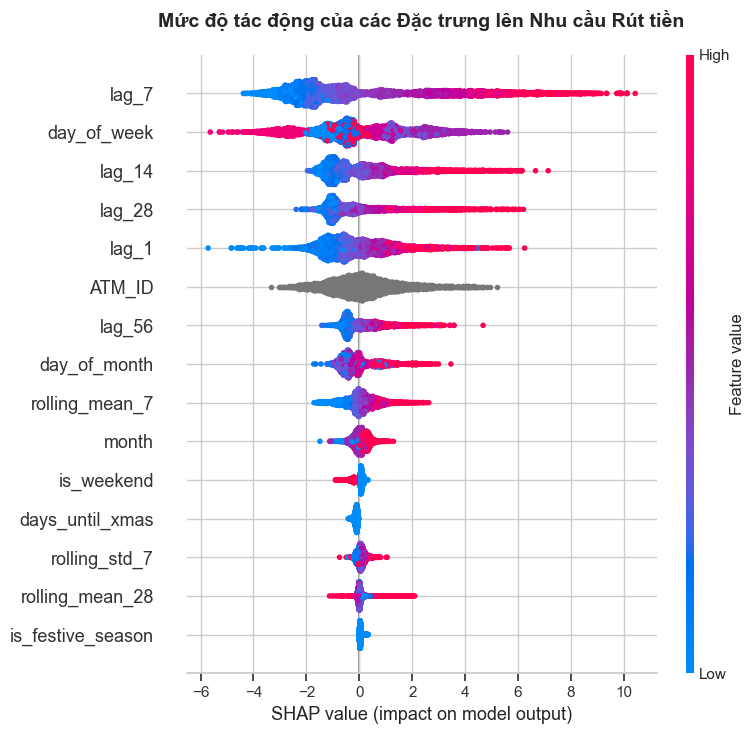


📊 2. Biểu đồ SHAP Bar Plot (Mức độ quan trọng tuyệt đối)


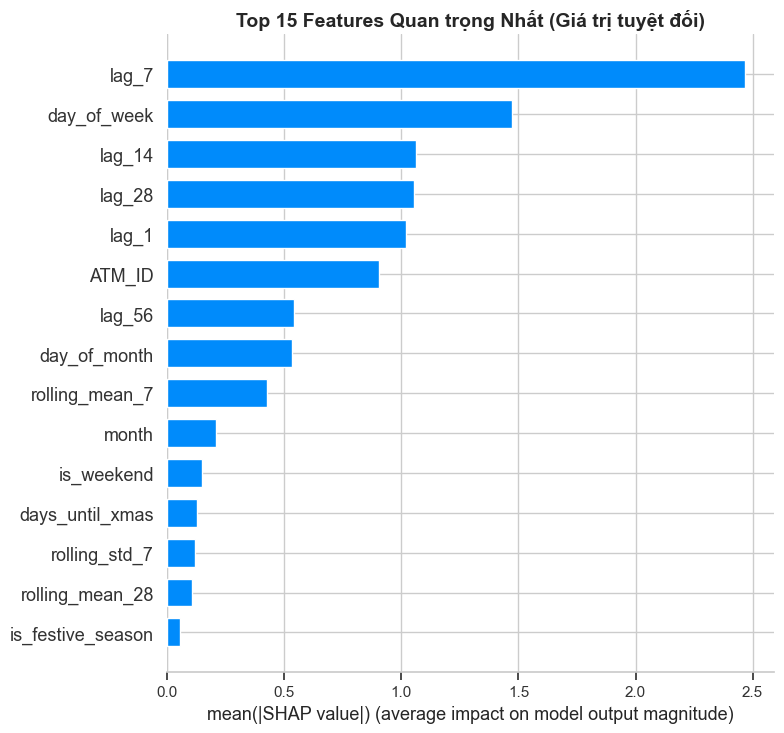


📊 3. Biểu đồ SHAP Dependence Plot cho Lag_7


<Figure size 800x600 with 0 Axes>

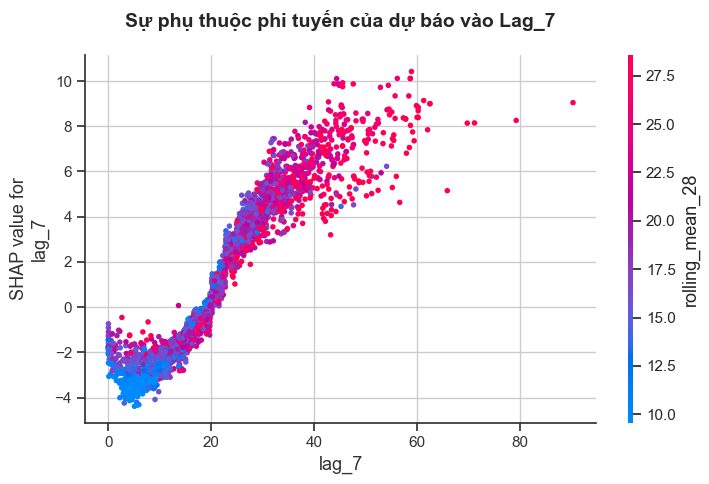

In [212]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Khởi tạo môi trường JS cho các biểu đồ tương tác (nếu dùng Jupyter)
shap.initjs()

def analyze_shap_lightgbm(model, test_feat):
    """
    Sử dụng SHAP để giải thích mô hình Global LightGBM.
    model: Đối tượng Booster trả về từ hàm lgb.train
    test_feat: Tập dữ liệu Test (hoặc Val) đã tạo features
    """
    print("🔍 Đang tính toán giá trị SHAP (Có thể mất khoảng 1-2 phút)...")
    
    # Chuẩn bị dữ liệu đầu vào (Giống hệt lúc đưa vào dự báo)
    feature_cols = [col for col in test_feat.columns if col not in ['Date', 'Withdrawal']]
    X_test = test_feat[feature_cols].copy()
    
    # Đảm bảo ATM_ID là category để SHAP đọc được
    X_test['ATM_ID'] = X_test['ATM_ID'].astype('category')
    
    # 2. Khởi tạo TreeExplainer cho LightGBM
    explainer = shap.TreeExplainer(model)
    
    # Tính toán SHAP values trên một tập mẫu (sample) để chạy nhanh hơn
    # Ở đây lấy ngẫu nhiên 5000 dòng từ tập Test để phân tích
    X_sample = X_test.sample(n=5000, random_state=42)
    shap_values = explainer.shap_values(X_sample)
    
    # ==========================================
    # BIỂU ĐỒ 1: SHAP SUMMARY PLOT (TỔNG QUAN)
    # ==========================================
    print("\n📊 1. Biểu đồ SHAP Summary Plot (Mức độ quan trọng & Chiều tác động)")
    plt.figure(figsize=(12, 8))
    # Hiển thị top 15 features quan trọng nhất
    shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
    plt.title("Mức độ tác động của các Đặc trưng lên Nhu cầu Rút tiền", fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # ==========================================
    # BIỂU ĐỒ 2: SHAP BAR PLOT (TRUNG BÌNH TUYỆT ĐỐI)
    # ==========================================
    print("\n📊 2. Biểu đồ SHAP Bar Plot (Mức độ quan trọng tuyệt đối)")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=15, show=False)
    plt.title("Top 15 Features Quan trọng Nhất (Giá trị tuyệt đối)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # ==========================================
    # BIỂU ĐỒ 3: DEPENDENCE PLOT (TƯƠNG TÁC PHI TUYẾN)
    # ==========================================
    print("\n📊 3. Biểu đồ SHAP Dependence Plot cho Lag_7")
    # Xem lag_7 tác động thế nào, và nó tương tác với is_weekend ra sao
    if 'lag_7' in X_sample.columns:
        plt.figure(figsize=(8, 6))
        shap.dependence_plot("lag_7", shap_values, X_sample, show=False)
        plt.title("Sự phụ thuộc phi tuyến của dự báo vào Lag_7", fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

# THỰC THI
# Lưu ý: 'lgb_model' là model được return từ hàm train_lightgbm_optimized_global của bạn
# (Nếu hàm cũ chưa return model, bạn hãy sửa thêm `return predictions, mean_test_smape, model` ở hàm train nhé)
analyze_shap_lightgbm(model=lgb_model_object, test_feat=test_feat)

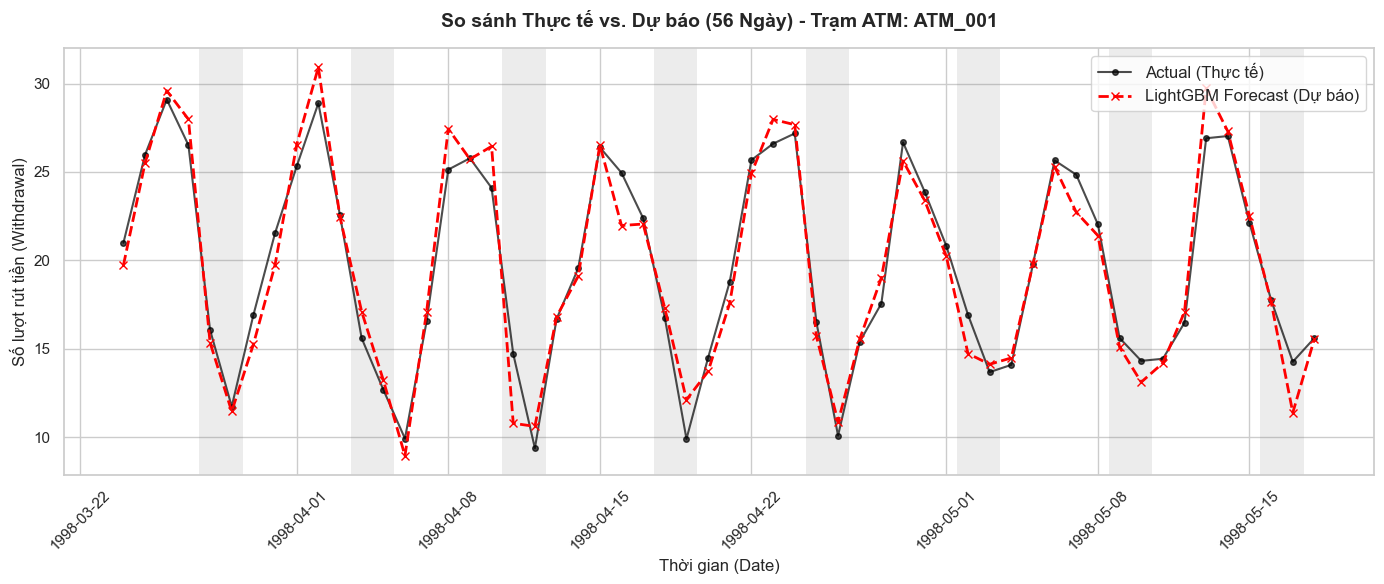

In [227]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_actual_vs_predicted_test(test_df, lgb_preds_dict, atm_id=None):
    """
    Vẽ biểu đồ so sánh dữ liệu Thực tế và Dự báo của LightGBM trên tập Test (56 ngày).
    """
    sns.set_theme(style="whitegrid")
    
    # Nếu không truyền atm_id, lấy ngẫu nhiên 1 ATM đầu tiên trong từ điển
    if atm_id is None:
        atm_id = list(lgb_preds_dict.keys())[0]
        
    # Lọc dữ liệu 56 ngày của ATM đó
    atm_data = test_df[test_df['ATM_ID'] == atm_id].copy()
    atm_data = atm_data.sort_values('Date')
    
    # Lấy mảng dự báo từ dictionary
    pred_values = lgb_preds_dict[atm_id]
    
    plt.figure(figsize=(14, 6))
    
    # Vẽ đường Thực tế
    plt.plot(atm_data['Date'], atm_data['Withdrawal'], label='Actual (Thực tế)', 
             color='black', marker='o', markersize=4, linestyle='-', linewidth=1.5, alpha=0.7)
    
    # Vẽ đường Dự báo LightGBM
    plt.plot(atm_data['Date'], pred_values, label='LightGBM Forecast (Dự báo)', 
             color='red', marker='x', markersize=6, linestyle='--', linewidth=2)
    
    plt.title(f'So sánh Thực tế vs. Dự báo (56 Ngày) - Trạm ATM: {atm_id}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Thời gian (Date)', fontsize=12)
    plt.ylabel('Số lượt rút tiền (Withdrawal)', fontsize=12)
    
    # Highlight các ngày cuối tuần (T7, CN) bằng các dải màu nền mờ
    weekends = atm_data[atm_data['Date'].dt.dayofweek >= 5]['Date']
    for we in weekends:
        plt.axvspan(we - pd.Timedelta(hours=12), we + pd.Timedelta(hours=12), 
                    color='gray', alpha=0.15, lw=0)
    
    # Ghi chú thêm cho biểu đồ
    plt.legend(loc='upper right', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# THỰC THI (Lấy thử 1 ATM có biến động rõ rệt để vẽ, ví dụ 'nn5_01' hoặc bạn tự thay tên)
plot_actual_vs_predicted_test(test_feat, global_lgb_predictions, atm_id=test_feat['ATM_ID'].unique()[0])

In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 0. DUMMY DATA GENERATION (MÔ PHỎNG DỮ LIỆU TẬP TEST)
# (Thay thế phần này bằng test_df và dictionary của bạn)
# ==========================================
test_dates = pd.date_range(start='1998-03-24', periods=56, freq='D') # 56 ngày tập test
np.random.seed(42)
# Giả lập số liệu thực tế có chu kỳ 7 ngày
actual_withdrawals = 20 + 8 * np.sin(np.arange(len(test_dates)) / (7/(2*np.pi))) + np.random.normal(0, 2, len(test_dates))
# Giả lập số liệu dự báo bám sát số thực tế (LightGBM)
predicted_withdrawals = actual_withdrawals + np.random.normal(0, 1.5, len(test_dates))

test_feat = pd.DataFrame({'Date': test_dates, 'Withdrawal': actual_withdrawals, 'ATM_ID': 'ATM_001'})
global_lgb_predictions = {'ATM_001': predicted_withdrawals}


# ==========================================
# 1. COLOR PALETTE & GLOBAL SETTINGS
# ==========================================
MAIN_BLUE = '#1f497d'   # Nhấn mạnh đường dự báo
ACTUAL_GREY = '#a6a6a6' # Dữ liệu thực tế
TEXT_GREY = '#595959'  
BG_HIGHLIGHT = '#f2f2f2' # Màu xám rất nhạt cho cuối tuần

sns.set_style("white") 
plt.rcParams['font.family'] = 'sans-serif' 
plt.rcParams['text.color'] = TEXT_GREY
plt.rcParams['axes.labelcolor'] = TEXT_GREY
plt.rcParams['xtick.color'] = TEXT_GREY
plt.rcParams['ytick.color'] = TEXT_GREY


def export_actual_vs_predicted_swd(test_df, lgb_preds_dict, atm_id=None, filename="plot_actual_vs_predicted.png"):
    """
    Generate and export Actual vs Predicted plot in English, 
    following Storytelling with Data principles.
    """
    # Nếu không truyền atm_id, lấy ngẫu nhiên 1 ATM đầu tiên
    if atm_id is None:
        atm_id = list(lgb_preds_dict.keys())[0]
        
    atm_data = test_df[test_df['ATM_ID'] == atm_id].copy()
    atm_data = atm_data.sort_values('Date')
    pred_values = lgb_preds_dict[atm_id]
    
    fig, ax = plt.subplots(figsize=(14, 5.5))
    
    # 1. VẼ HIGHLIGHT CUỐI TUẦN (Vẽ trước để nằm dưới đáy - zorder=0)
    weekends = atm_data[atm_data['Date'].dt.dayofweek >= 5]['Date']
    for we in weekends:
        ax.axvspan(we - pd.Timedelta(hours=12), we + pd.Timedelta(hours=12), 
                   color=BG_HIGHLIGHT, alpha=0.6, lw=0, zorder=0)

    # 2. VẼ DỮ LIỆU THỰC TẾ (Background Truth)
    ax.plot(atm_data['Date'], atm_data['Withdrawal'], color=ACTUAL_GREY, 
            marker='o', markersize=4, linestyle='-', linewidth=1.5, zorder=2)
    
    # 3. VẼ DỮ LIỆU DỰ BÁO (Highlight)
    ax.plot(atm_data['Date'], pred_values, color=MAIN_BLUE, 
            marker='None', linestyle='-', linewidth=2.5, zorder=3)
            
    # 4. CHÚ THÍCH TRỰC TIẾP (DIRECT LABELING)
    last_date = atm_data['Date'].iloc[-1]
    last_actual = atm_data['Withdrawal'].iloc[-1]
    last_pred = pred_values[-1]
    
    # Căn chỉnh để chữ không bị đè lên nhau nếu điểm cuối trùng nhau
    offset = 1.5 if last_pred >= last_actual else -1.5
    
    ax.text(last_date + pd.Timedelta(days=1), last_actual - offset, 'Actual', 
            color=ACTUAL_GREY, fontsize=12, fontweight='bold', va='center')
    ax.text(last_date + pd.Timedelta(days=1), last_pred + offset, 'LightGBM\nForecast', 
            color=MAIN_BLUE, fontsize=12, fontweight='bold', va='center')

    # 5. TIÊU ĐỀ KỂ CHUYỆN (ACTIONABLE TITLE)
    ax.set_title(f"Global LightGBM closely tracks the actual variance over the 56-day blind test horizon (ATM: {atm_id})", 
                 fontsize=14, fontweight='bold', color=MAIN_BLUE, loc='left', pad=20)
    
    # 6. ĐỊNH DẠNG TRỤC VÀ DỌN DẸP (DECLUTTERING)
    ax.set_xlabel('') # Bỏ chữ "Date" vì trục thời gian đã quá rõ ràng
    ax.set_ylabel('Withdrawal Volume', fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%Y')) # Hiển thị VD: 24 Mar 1998
    
    sns.despine(ax=ax)
    ax.yaxis.grid(True, linestyle='-', color='#eeeeee', zorder=1) # Chỉ giữ lưới ngang mờ
    ax.xaxis.grid(False)
    
    # Tăng margin bên phải một chút để đủ chỗ hiển thị text trực tiếp
    ax.set_xlim(atm_data['Date'].iloc[0] - pd.Timedelta(days=1), 
                last_date + pd.Timedelta(days=6))
    
    # 7. XUẤT FILE ẢNH
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ Đã lưu biểu đồ thành công tại file: {filename}")
    plt.close(fig)

# ==========================================
# THỰC THI HÀM
# ==========================================
# Gọi hàm với dữ liệu thực tế của bạn
export_actual_vs_predicted_swd(test_feat, global_lgb_predictions, atm_id='ATM_001', filename="plot6_actual_vs_predicted.png")

✅ Đã lưu biểu đồ thành công tại file: plot6_actual_vs_predicted.png
